In [81]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key=" ")
# project = rf.workspace("parkingspace-93kda").project("plant-disease-d6iv1")
# version = project.version(1)
# dataset = version.download("coco")
                

In [82]:
import json
bbox=[]
with open ("plant-disease-1/train/_annotations.coco.json","r") as file:
    data=json.load(file)
for i,box in enumerate(data["annotations"]):
            print(box['bbox'])
            break

[76, 58, 449, 449]


In [83]:
print(data.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [84]:
data["images"][10]

{'id': 10,
 'license': 1,
 'file_name': '12019ba6-405d-45b7-b0e6-5a6a665de0e7___Com-G_SpM_FL-8624_JPG_jpg.rf.16611a9d3b06aeffcf7d09a0382b0b28.jpg',
 'height': 640,
 'width': 640,
 'date_captured': '2025-01-15T04:06:04+00:00'}

In [85]:
data["annotations"][200]

{'id': 200,
 'image_id': 88,
 'category_id': 4,
 'bbox': [143, 281, 195.5, 302],
 'area': 59041,
 'segmentation': [],
 'iscrowd': 0}

In [86]:
print([
    ann for ann in data["annotations"]
    if ann["image_id"] == data["images"][10]["id"]
][0]['bbox'])
    

[53, 51, 498, 526.5]


In [87]:
print(data["categories"])
for i,disease in enumerate(data["categories"]):
    print(i,disease["name"])

[{'id': 0, 'name': 'Plants', 'supercategory': 'none'}, {'id': 1, 'name': 'ALS', 'supercategory': 'Plants'}, {'id': 2, 'name': 'Angular Leafspot', 'supercategory': 'Plants'}, {'id': 3, 'name': 'Anthracnose Fruit Rot', 'supercategory': 'Plants'}, {'id': 4, 'name': 'Bean Rust', 'supercategory': 'Plants'}, {'id': 5, 'name': 'Blossom Blight', 'supercategory': 'Plants'}, {'id': 6, 'name': 'Gray Mold', 'supercategory': 'Plants'}, {'id': 7, 'name': 'Leaf Spot', 'supercategory': 'Plants'}, {'id': 8, 'name': 'Powdery Mildew Fruit', 'supercategory': 'Plants'}, {'id': 9, 'name': 'Powdery Mildew Leaf', 'supercategory': 'Plants'}, {'id': 10, 'name': 'disease', 'supercategory': 'Plants'}, {'id': 11, 'name': 'leaf mold', 'supercategory': 'Plants'}, {'id': 12, 'name': 'spider mites', 'supercategory': 'Plants'}]
0 Plants
1 ALS
2 Angular Leafspot
3 Anthracnose Fruit Rot
4 Bean Rust
5 Blossom Blight
6 Gray Mold
7 Leaf Spot
8 Powdery Mildew Fruit
9 Powdery Mildew Leaf
10 disease
11 leaf mold
12 spider mite

In [88]:
print(len(data["images"]))

3301


In [89]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import cv2
import json
import os

In [90]:
data["images"][10]

{'id': 10,
 'license': 1,
 'file_name': '12019ba6-405d-45b7-b0e6-5a6a665de0e7___Com-G_SpM_FL-8624_JPG_jpg.rf.16611a9d3b06aeffcf7d09a0382b0b28.jpg',
 'height': 640,
 'width': 640,
 'date_captured': '2025-01-15T04:06:04+00:00'}

In [91]:
data['annotations'][10]

{'id': 10,
 'image_id': 4,
 'category_id': 4,
 'bbox': [186, 344, 167.5, 222],
 'area': 37185,
 'segmentation': [],
 'iscrowd': 0}

In [92]:
box=[]
for i,image_path in enumerate(data["images"]):
    image_id=image_path["id"]
    j=[]
    for annotation in data["annotations"]:
        if image_id==annotation["image_id"]:
           j.append(annotation["bbox"])
    box.append(j)
           

        

            
    

In [93]:
data["images"][1]

{'id': 1,
 'license': 1,
 'file_name': '1619348833754_jpg.rf.1457a0e8b9ee08043d4b57cd656cf32f.jpg',
 'height': 640,
 'width': 640,
 'date_captured': '2025-01-15T04:06:04+00:00'}

In [94]:
tensor=torch.tensor(box[1])

tensor
print(type(tensor))
print(tensor)
print(type(tensor[0]))

<class 'torch.Tensor'>
tensor([[212.0000,  81.0000, 134.5000, 253.0000],
        [272.0000, 296.0000, 137.5000, 338.5000],
        [534.0000, 109.0000,  76.5000,  92.5000]])
<class 'torch.Tensor'>


In [95]:
l=[]
for b in box :
    if len(b)>1:
        l.append(b)
print(len(l))

1392


In [96]:
box[:4]

[[[76, 58, 449, 449]],
 [[212, 81, 134.5, 253], [272, 296, 137.5, 338.5], [534, 109, 76.5, 92.5]],
 [[93, 27, 517.5, 496.5]],
 [[165, 114, 182, 294],
  [279, 364, 156.5, 215],
  [353, 37, 132.5, 343],
  [498, 330, 37, 154],
  [84, 0, 114.5, 166]]]

In [97]:
class PlantDiseaseDataset(Dataset):
    def __init__(self,folder_path,transform=None):
        self.folder_path=folder_path
        self.images=[]
        self.bbox=[]
        self.category_id=[]
        self.area=[]
        self.crowd=[]
        
        self.transform=transform
        
        
        with open (os.path.join(self.folder_path,"_annotations.coco.json"),"r" ) as file:
            data=json.load(file)
        self.data=data
        
        for i,image_path in enumerate(data["images"][:500]):
            image_id=image_path["id"]
            Boxes=[]
            labels=[]
            area=[]
            crowd=[]
            for annotation in data["annotations"]:
                if image_id==annotation["image_id"]:
                    Boxes.append(annotation["bbox"])
                    labels.append(annotation["category_id"])
                    area.append(annotation["area"])
                    crowd.append(annotation["iscrowd"])
                    
            
            self.bbox.append(Boxes)
                    
                     
            self.category_id.append(labels)
            self.area.append(area)
            self.crowd.append(crowd)
            
            
        
            
            self.images.append(image_path["file_name"])
            
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        
        bbox=self.bbox[idx]
        bbox = torch.tensor(self.bbox[idx], dtype=torch.float32)
        category_id=self.category_id[idx]
        category_id = torch.tensor(category_id, dtype=torch.int64)
        
        area=self.area[idx]
        area = torch.tensor(area, dtype=torch.float32)
        
        is_crowd=self.crowd[idx]
        is_crowd = torch.tensor(is_crowd, dtype=torch.long)
        
        boxes=[]
        for box in bbox:
           x,y,w,h=box
           boxes.append([x,y,x+w,y+h])
           
        boxes=torch.tensor(boxes,dtype=torch.float32)
           
                
                
            
        
        target = {
            "boxes": boxes,
            "labels": category_id,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": is_crowd
        }
        
        

        image_path=os.path.join(self.folder_path,self.images[idx])
        image=cv2.imread(image_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        
        if self.transform:
           image= self.transform(image)
            
        tensor=torch.from_numpy(image)
        tensor=tensor.permute(2,0,1).float()/255.0
        
        
        return tensor,target
        
        
        




In [98]:
import matplotlib.pyplot as plt
import numpy as np

In [99]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [100]:
train_dataset=PlantDiseaseDataset("plant-disease-1/train")
test_dataset=PlantDiseaseDataset("plant-disease-1/test")
valid_dataset=PlantDiseaseDataset("plant-disease-1/test")


train_data_loader=DataLoader(dataset=train_dataset,batch_size=3,shuffle=True,collate_fn=collate_fn)
test_data_loader=DataLoader(dataset=test_dataset,batch_size=3,shuffle=True,collate_fn=collate_fn)
valid_data_loader=DataLoader(dataset=valid_dataset,batch_size=3,shuffle=True,collate_fn=collate_fn)



In [101]:
len(train_data_loader)

167

{0: 'Plants', 1: 'ALS', 2: 'Angular Leafspot', 3: 'Anthracnose Fruit Rot', 4: 'Bean Rust', 5: 'Blossom Blight', 6: 'Gray Mold', 7: 'Leaf Spot', 8: 'Powdery Mildew Fruit', 9: 'Powdery Mildew Leaf', 10: 'disease', 11: 'leaf mold', 12: 'spider mites'}
{'boxes': tensor([[119.,  18., 622., 626.]]), 'labels': tensor([10]), 'image_id': tensor([143]), 'area': tensor([305824.]), 'iscrowd': tensor([0])}


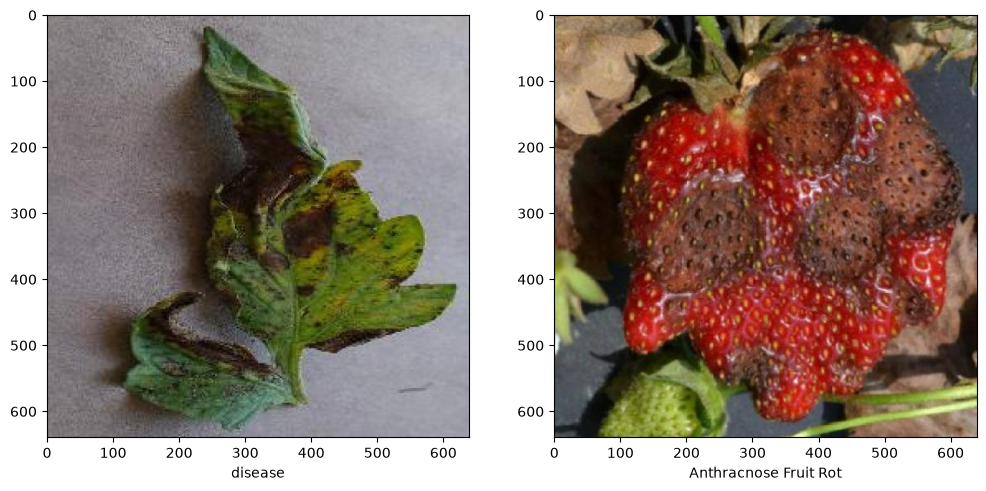

In [102]:
classes={}
for i,disease in enumerate(data["categories"]):
            classes[i]=disease["name"]
            
print(classes)

for X, y in train_data_loader:
   print(y[0])
   
   
   fig, axs = plt.subplots(1, 2,figsize=(12,6))
   X=X[:2]
  
   
   for i ,k in enumerate(X):
      im = k.permute(1, 2, 0).numpy()
     
      
      axs[i].imshow(im)
      
     
      
      axs[i].set_xlabel(classes[y[i]["labels"][0].item()])
      # axs[i].axis("off")
      
   plt.show()
   break
      



      


In [103]:
import torch

In [104]:
import torchvision
from torchvision.models.detection import( fasterrcnn_resnet50_fpn,
                                         FasterRCNN_ResNet50_FPN_Weights)

In [105]:
model=fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

In [106]:
device="cuda" if torch.cuda.is_available() else "cpu"

device

'cpu'

In [107]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes=len(classes)+1 

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
    
)


In [108]:
# model.to(device=device)

In [109]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [110]:
for images, targets in valid_data_loader:
    print(targets[0])
    for k, v in targets[0].items():
        print(k, type(v))
    break

{'boxes': tensor([[304., 231., 378., 294.],
        [358., 370., 427., 425.],
        [274., 367., 341., 456.],
        [153., 214., 221., 256.]]), 'labels': tensor([5, 5, 5, 5]), 'image_id': tensor([16]), 'area': tensor([4662., 3795., 5963., 2856.]), 'iscrowd': tensor([0, 0, 0, 0])}
boxes <class 'torch.Tensor'>
labels <class 'torch.Tensor'>
image_id <class 'torch.Tensor'>
area <class 'torch.Tensor'>
iscrowd <class 'torch.Tensor'>


In [ ]:
num_epochs = 4
best_val_loss = float("inf")

model.train()

for epoch in range(num_epochs):

    running_loss = 0

    for i,(images, targets )in enumerate(train_data_loader):

        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        losses= model(images, targets)
        print(i,losses)
      

        loss=sum(v for v in losses.values())
        
        



        

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_data_loader)


  


    

    print(
            f"Epoch [{epoch+1}/{num_epochs}] |"
            f"Train Loss: {avg_train_loss:.4f} |"
            
            
            
    )

    
    if avg_train_loss < best_val_loss:

            best_val_loss = avg_train_loss

            torch.save(model, "best_model.pth")

            print("Best model saved!")

In [112]:
image, target = train_dataset[0]

print(target)

for k, v in target.items():
    print(k, v.shape, v.dtype)

{'boxes': tensor([[ 76.,  58., 525., 507.]]), 'labels': tensor([11]), 'image_id': tensor([0]), 'area': tensor([201601.]), 'iscrowd': tensor([0])}
boxes torch.Size([1, 4]) torch.float32
labels torch.Size([1]) torch.int64
image_id torch.Size([1]) torch.int64
area torch.Size([1]) torch.float32
iscrowd torch.Size([1]) torch.int64


In [113]:
model=torch.load("best_model.pth",weights_only=False)


In [114]:
classes={}
for i,disease in enumerate(data["categories"]):
            classes[i]=disease["name"]

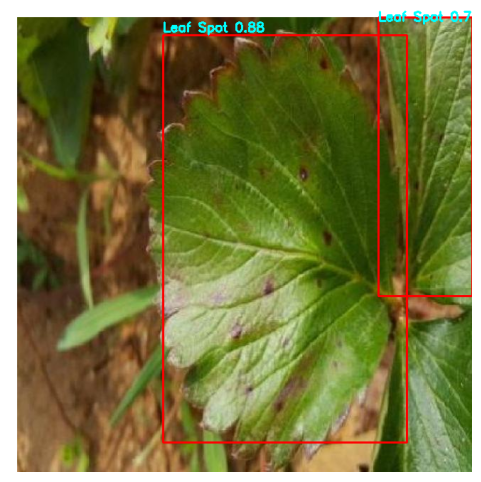

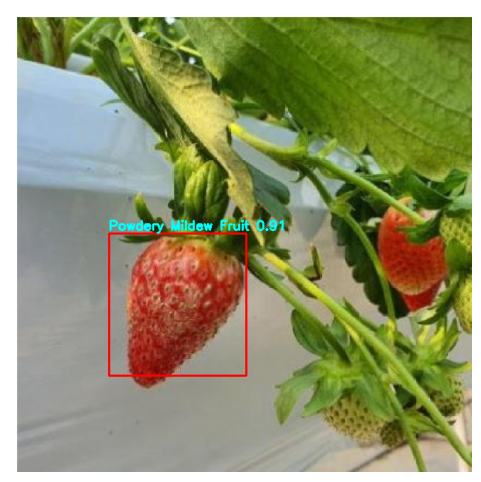

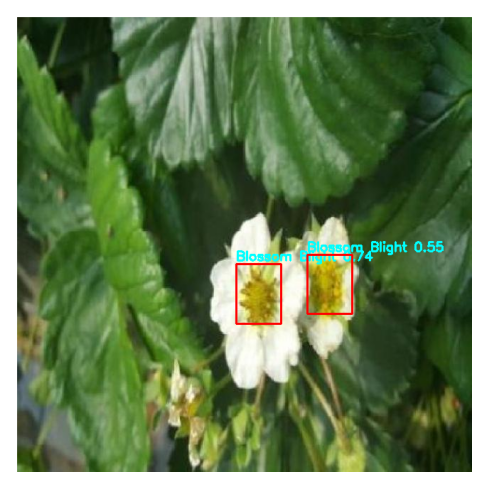

In [115]:
model.eval()

for images, targets in valid_data_loader:

    images = [img.to(device) for img in images]

    with torch.no_grad():
        predictions = model(images)

 
    for i in range(len(images)):

        image = images[i].cpu().permute(1, 2, 0).numpy()

        canvas = np.ones((650, 650, 3), dtype=np.float32)
        canvas[10:650, 10:650] = image

        
        for box, label, score in zip(
            predictions[i]["boxes"],
            predictions[i]["labels"],
            predictions[i]["scores"]
        ):

          
            if score<0.5:
                continue
            
            x1, y1, x2, y2 = box.int().tolist()

            x1 += 10
            y1 += 10
            x2 += 10
            y2 += 10

            cv2.rectangle(canvas, (x1, y1), (x2, y2), (1, 0, 0), 2)

            cv2.putText(
                canvas,
                f"{classes[label.item()]} {score:.2f}",
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 1, 1),
                2,
                cv2.LINE_AA
            )

        plt.figure(figsize=(6, 6))
        plt.imshow(canvas)
        plt.axis("off")
        plt.show()

    break

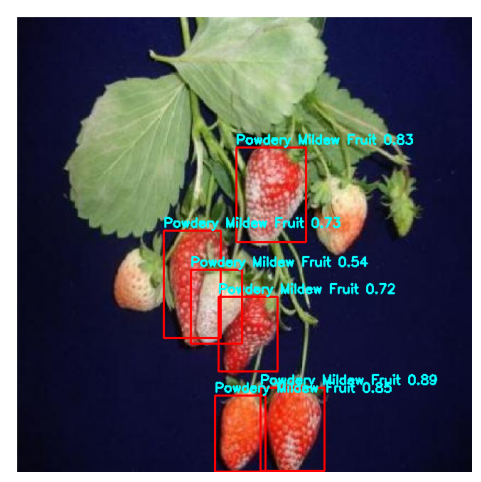

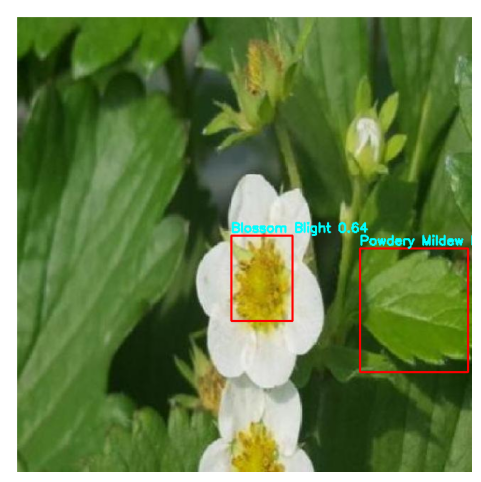

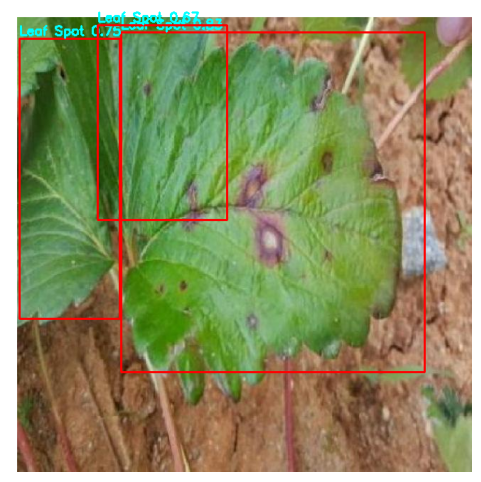

In [116]:
model.eval()

for images, targets in test_data_loader:

    images = [img.to(device) for img in images]

    with torch.no_grad():
        predictions = model(images)
    
   

 
    for i in range(len(images)):

        image = images[i].cpu().permute(1, 2, 0).numpy()

        canvas = np.ones((650, 650, 3), dtype=np.float32)
        canvas[10:650, 10:650] = image

        
        for box, label, score in zip(
            predictions[i]["boxes"],
            predictions[i]["labels"],
            predictions[i]["scores"]
        ):

          
            if score<0.5:
                continue
            
            x1, y1, x2, y2 = box.int().tolist()

            x1 += 10
            y1 += 10
            x2 += 10
            y2 += 10

            cv2.rectangle(canvas, (x1, y1), (x2, y2), (1, 0, 0), 2)

            cv2.putText(
                canvas,
                f"{classes[label.item()]} {score:.2f}",
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 1, 1),
                2,
                cv2.LINE_AA
            )

        plt.figure(figsize=(6, 6))
        plt.imshow(canvas)
        plt.axis("off")
        plt.show()

    break

In [117]:
for images, targets in test_data_loader:
    print(type(images[0]))
    break

<class 'torch.Tensor'>


In [118]:
import cv2
import torch

image = cv2.imread("plant-disease-1/test/gray_mold243_jpg.rf.9e5e9d0ea3d331c103229f464befdd42.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0


image = image.to(device)

model.eval()

with torch.no_grad():
    pred = model([image])



In [119]:
type(image)
image.shape
image=image.permute(1,2,0)
image.shape

torch.Size([640, 640, 3])

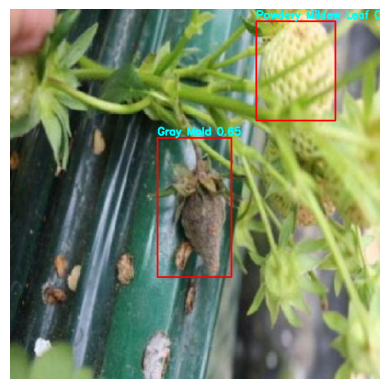

In [120]:

for box,label,score in zip(pred[0]["boxes"],pred[0]["labels"],pred[0]["scores"]):
    if score<.5:
        continue
    x1,y1,x2,y2=box.int().tolist()
    
   
    
    image = np.ascontiguousarray(image)
    
    
    cv2.rectangle(image,(x1,y1),(x2,y2),(1,0,0),2)
    cv2.putText(image,
                f'{classes[label.item()]} {score:.2f}',
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 1, 1),
                2,
                cv2.LINE_AA)
    
plt.imshow(image)
plt.axis("off")
plt.show()

# conclusion
The predictions are pretty good but i only trained my data on 500 images even though my train dataset has more than 3k images and I only train my model with 4 epochs .my laptop does not support for training bigger models it nearly took  10 hours to train this model

NOTE:- If u want to have a good model try epoch sizes like 25,50,100 and use all train dataset images